In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("delivery_history.csv.csv")

df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [7]:
df.shape

(10324, 33)

In [8]:
df.columns.tolist()

['ID',
 'Project Code',
 'PQ #',
 'PO / SO #',
 'ASN/DN #',
 'Country',
 'Managed By',
 'Fulfill Via',
 'Vendor INCO Term',
 'Shipment Mode',
 'PQ First Sent to Client Date',
 'PO Sent to Vendor Date',
 'Scheduled Delivery Date',
 'Delivered to Client Date',
 'Delivery Recorded Date',
 'Product Group',
 'Sub Classification',
 'Vendor',
 'Item Description',
 'Molecule/Test Type',
 'Brand',
 'Dosage',
 'Dosage Form',
 'Unit of Measure (Per Pack)',
 'Line Item Quantity',
 'Line Item Value',
 'Pack Price',
 'Unit Price',
 'Manufacturing Site',
 'First Line Designation',
 'Weight (Kilograms)',
 'Freight Cost (USD)',
 'Line Item Insurance (USD)']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [10]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing[missing["Missing Values"] > 0].sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
Dosage,1736,16.82
Shipment Mode,360,3.49
Line Item Insurance (USD),287,2.78


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [13]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(col)
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts(dropna=False).head(10))


Project Code
Unique values: 142
Project Code
116-ZA-T30    768
104-CI-T30    729
151-NG-T30    628
114-UG-T30    596
108-VN-T30    522
106-HT-T30    450
111-MZ-T30    431
110-ZM-T30    406
109-TZ-T30    369
107-RW-T30    340
Name: count, dtype: int64

PQ #
Unique values: 1237
PQ #
Pre-PQ Process    2681
FPQ-14942          205
FPQ-12522          154
FPQ-13973          110
FPQ-4537            98
FPQ-8840            90
FPQ-5303            78
FPQ-7175            78
FPQ-6262            75
FPQ-5023            70
Name: count, dtype: int64

PO / SO #
Unique values: 6233
PO / SO #
SCMS-199289    67
SCMS-199283    63
SCMS-183950    55
SCMS-215370    38
SCMS-259075    38
SCMS-259079    33
SCMS-215410    26
SCMS-23500     26
SCMS-259078    20
SCMS-162440    20
Name: count, dtype: int64

ASN/DN #
Unique values: 7030
ASN/DN #
ASN-19166    54
ASN-24415    38
ASN-23875    26
ASN-32138    19
ASN-28034    17
ASN-30792    17
ASN-28036    17
DN-304       17
ASN-28033    17
ASN-1520     16
Name: count, dt

In [14]:
date_cols = [
    "Scheduled Delivery Date",
    "Delivered to Client Date",
    "Delivery Recorded Date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

C:\Users\S B\AppData\Local\Temp\ipykernel_3512\3265364277.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
C:\Users\S B\AppData\Local\Temp\ipykernel_3512\3265364277.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
C:\Users\S B\AppData\Local\Temp\ipykernel_3512\3265364277.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


In [15]:
df["Delivery_Delay_Days"] = (
    df["Delivered to Client Date"]
    - df["Scheduled Delivery Date"]
).dt.days

In [16]:
df["Delivery_Delay_Days"].describe()

count    10324.000000
mean        -6.023537
std         27.233640
min       -372.000000
25%         -3.000000
50%          0.000000
75%          0.000000
max        192.000000
Name: Delivery_Delay_Days, dtype: float64

In [17]:
df["Delivery_Status"] = np.where(
    df["Delivery_Delay_Days"] > 0,
    "Late",
    "On Time"
)

In [18]:
df["Delivery_Status"].value_counts()

Delivery_Status
On Time    9138
Late       1186
Name: count, dtype: int64

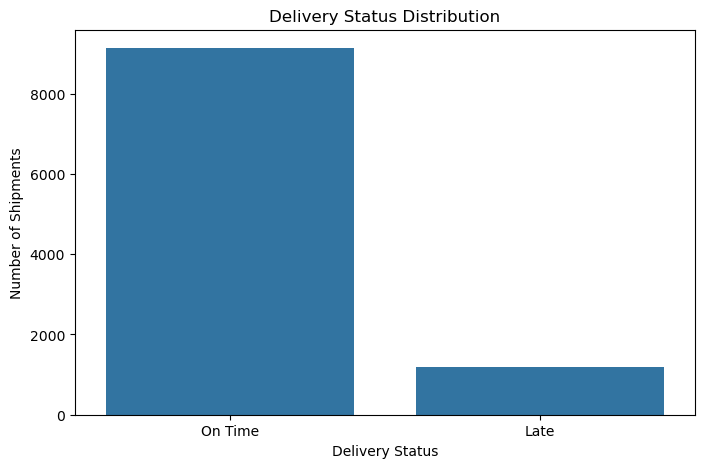

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Delivery_Status"
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")

plt.show()

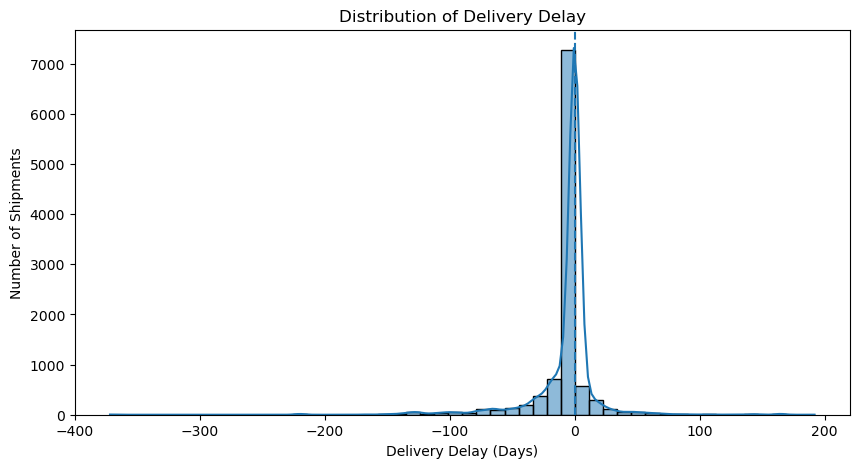

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Delivery_Delay_Days",
    bins=50,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Number of Shipments")

plt.show()

In [21]:
vendor_performance = (
    df.groupby("Vendor")
      .agg(
          Total_Shipments=("ID", "count"),
          Late_Shipments=("Delivery_Status", lambda x: (x == "Late").sum()),
          Average_Delay=("Delivery_Delay_Days", "mean")
      )
)

vendor_performance["Late_Rate"] = (
    vendor_performance["Late_Shipments"]
    / vendor_performance["Total_Shipments"]
    * 100
)

vendor_performance.sort_values(
    "Late_Rate",
    ascending=False
).head(10)

,Total_Shipments,Late_Shipments,Average_Delay,Late_Rate
Vendor,,,,
SCMS from RDC,5404,927,-8.284049,17.153960
BIO-RAD LABORATORIES (FRANCE),28,4,2.107143,14.285714
Aurobindo Pharma Limited,668,94,4.411677,14.071856
CIPLA LIMITED,175,23,4.777143,13.142857
"Orgenics, Ltd",754,98,0.838196,12.997347
SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LABORATORIES LIMITED),9,1,0.333333,11.111111
REINBOLD EXPORT IMPORT,12,1,-8.250000,8.333333
EMCURE PHARMACEUTICALS LTD,41,2,1.390244,4.878049
Abbott GmbH & Co. KG,21,1,2.285714,4.761905


In [22]:
shipment_mode = (
    df.groupby("Shipment Mode")
      .agg(
          Total_Shipments=("ID", "count"),
          Average_Delay=("Delivery_Delay_Days", "mean"),
          Late_Rate=("Delivery_Status",
                     lambda x: (x == "Late").mean() * 100)
      )
      .sort_values("Late_Rate", ascending=False)
)

shipment_mode

,Total_Shipments,Average_Delay,Late_Rate
Shipment Mode,,,
Ocean,371,5.870620,17.520216
Truck,2830,-9.921908,16.077739
Air Charter,650,-19.036923,11.538462
Air,6113,-3.763782,9.602487


In [23]:
country_performance = (
    df.groupby("Country")
      .agg(
          Total_Shipments=("ID", "count"),
          Average_Delay=("Delivery_Delay_Days", "mean"),
          Late_Rate=("Delivery_Status",
                     lambda x: (x == "Late").mean() * 100)
      )
)

country_performance.sort_values(
    "Late_Rate",
    ascending=False
).head(15)

,Total_Shipments,Average_Delay,Late_Rate
Country,,,
Burundi,98,-8.448980,38.775510
Senegal,3,1.000000,33.333333
Togo,3,5.333333,33.333333
"Congo, DRC",333,11.240240,24.924925
Benin,13,2.384615,23.076923
Mozambique,631,-1.209192,18.383518
Zambia,683,-5.234261,15.812592
Zimbabwe,538,-11.007435,14.312268
Ghana,58,-0.224138,13.793103


In [24]:
product_performance = (
    df.groupby("Product Group")
      .agg(
          Shipments=("ID", "count"),
          Quantity=("Line Item Quantity", "sum"),
          Shipment_Value=("Line Item Value", "sum"),
          Average_Delay=("Delivery_Delay_Days", "mean"),
          Late_Rate=("Delivery_Status",
                     lambda x: (x == "Late").mean() * 100)
      )
)

product_performance

,Shipments,Quantity,Shipment_Value,Average_Delay,Late_Rate
Product Group,,,,,
ACT,16,134286,6.643809e+05,-10.562500,0.000000
ANTM,22,21023,2.741766e+05,-2.772727,0.000000
ARV,8550,185008389,1.413220e+09,-7.244094,12.549708
HRDT,1728,4098414,2.133448e+08,-0.011574,6.539352
MRDT,8,2978,8.106510e+04,0.000000,0.000000


In [25]:
# Cleaning pipeline for the delivery dataset
# 1) Remove duplicates and normalize text fields
# 2) Convert date columns to datetime
# 3) Fill missing categorical and numeric values sensibly
# 4) Create a consistent delivery status field

# Make a safe copy before modifying the original data

df_clean = df.copy()

# Standardize text values
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace({'nan': np.nan, 'None': np.nan, 'NaN': np.nan})

# Remove exact duplicate records
initial_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().copy()

# Fill missing category values
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

# Fill missing numeric values with median
num_cols = df_clean.select_dtypes(include=['number']).columns
for col in num_cols:
    if df_clean[col].isnull().any():
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

# Parse date columns
for col in ['Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Create delivery delay and status features
if {'Scheduled Delivery Date', 'Delivered to Client Date'}.issubset(df_clean.columns):
    df_clean['Delivery_Delay_Days'] = (
        df_clean['Delivered to Client Date'] - df_clean['Scheduled Delivery Date']
    ).dt.days

    df_clean['Delivery_Status'] = np.where(
        df_clean['Delivery_Delay_Days'] > 0,
        'Late',
        np.where(df_clean['Delivery_Delay_Days'] < 0, 'Early', 'On Time')
    )

# Print a quick validation summary
print(f"Original rows: {initial_rows}")
print(f"Rows after duplicate removal: {df_clean.shape[0]}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(df_clean.head().to_string(index=False))


Original rows: 10324
Rows after duplicate removal: 10324
Missing values remaining: 0
 ID Project Code           PQ # PO / SO # ASN/DN #       Country Managed By Fulfill Via Vendor INCO Term Shipment Mode PQ First Sent to Client Date PO Sent to Vendor Date Scheduled Delivery Date Delivered to Client Date Delivery Recorded Date Product Group Sub Classification                                                           Vendor                                    Item Description                       Molecule/Test Type     Brand  Dosage     Dosage Form  Unit of Measure (Per Pack)  Line Item Quantity  Line Item Value  Pack Price  Unit Price            Manufacturing Site First Line Designation Weight (Kilograms) Freight Cost (USD)  Line Item Insurance (USD)  Delivery_Delay_Days Delivery_Status
  1   100-CI-T01 Pre-PQ Process    SCMS-4    ASN-8 Côte d'Ivoire   PMO - US Direct Drop              EXW           Air               Pre-PQ Process      Date Not Captured              2006-06-02         

Delivery status summary:
Delivery_Status  Count  Share_%
        On Time   6324    61.26
          Early   2814    27.26
           Late   1186    11.49

Average delay (days): -6.02
Median delay (days): 0.00
Late delivery rate: 11.49%

Top country performance:
            Total_Shipments  Average_Delay  Late_Rate
Country                                              
Burundi                  98      -8.448980  38.775510
Senegal                   3       1.000000  33.333333
Togo                      3       5.333333  33.333333
Congo, DRC              333      11.240240  24.924925
Benin                    13       2.384615  23.076923
Mozambique              631      -1.209192  18.383518
Zambia                  683      -5.234261  15.812592
Zimbabwe                538     -11.007435  14.312268
Ghana                    58      -0.224138  13.793103
Guatemala                15      -1.000000  13.333333

Top vendor performance:
                                                                  

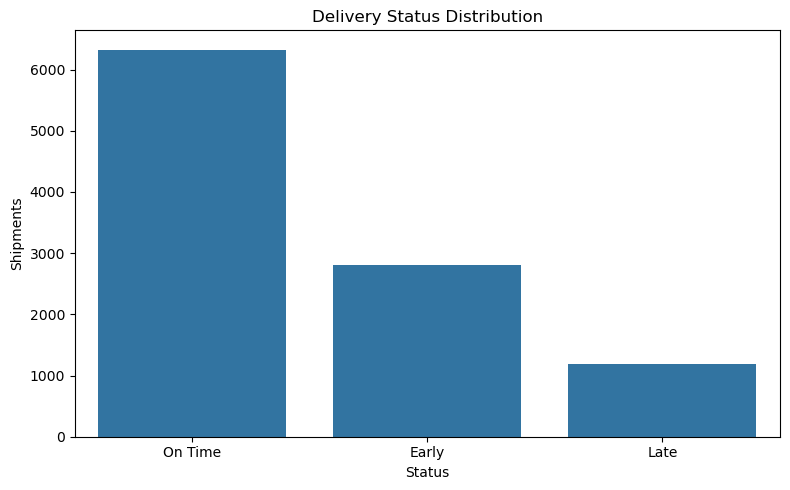

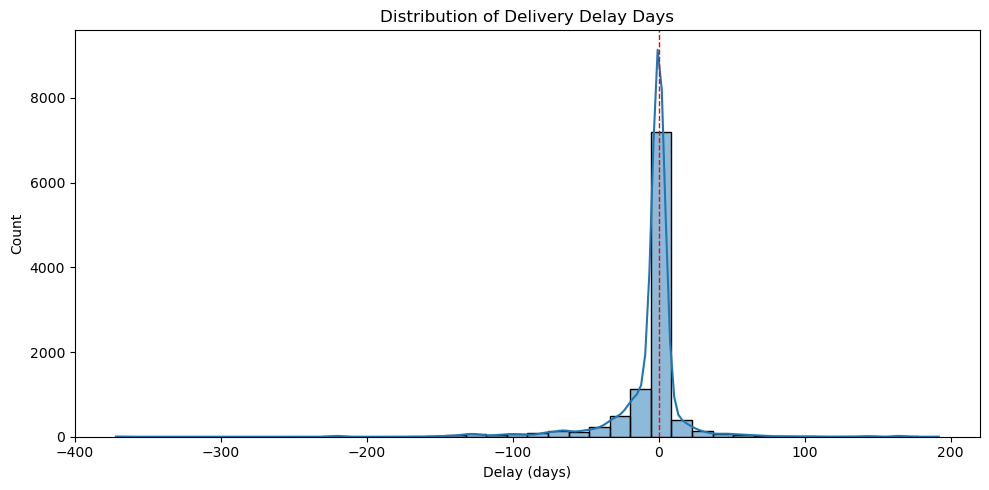

In [27]:
# Analytics summary: operational KPIs and key business findings

# Delivery status summary
status_summary = df_clean['Delivery_Status'].value_counts().reset_index()
status_summary.columns = ['Delivery_Status', 'Count']
status_summary['Share_%'] = (status_summary['Count'] / status_summary['Count'].sum() * 100).round(2)

print('Delivery status summary:')
print(status_summary.to_string(index=False))

# Core KPI calculations
avg_delay = df_clean['Delivery_Delay_Days'].mean()
median_delay = df_clean['Delivery_Delay_Days'].median()
late_rate = (df_clean['Delivery_Status'].eq('Late').mean() * 100).round(2)

print(f"\nAverage delay (days): {avg_delay:.2f}")
print(f"Median delay (days): {median_delay:.2f}")
print(f"Late delivery rate: {late_rate:.2f}%")

# Country-wise delay performance
country_performance = (
    df_clean.groupby('Country')
    .agg(
        Total_Shipments=('ID', 'count'),
        Average_Delay=('Delivery_Delay_Days', 'mean'),
        Late_Rate=('Delivery_Status', lambda x: (x == 'Late').mean() * 100)
    )
    .sort_values('Late_Rate', ascending=False)
)

print('\nTop country performance:')
print(country_performance.head(10).to_string())

# Vendor-wise delay performance
vendor_performance = (
    df_clean.groupby('Vendor')
    .agg(
        Total_Shipments=('ID', 'count'),
        Average_Delay=('Delivery_Delay_Days', 'mean'),
        Late_Rate=('Delivery_Status', lambda x: (x == 'Late').mean() * 100)
    )
    .sort_values('Late_Rate', ascending=False)
)

print('\nTop vendor performance:')
print(vendor_performance.head(10).to_string())

# Product group performance
product_performance = (
    df_clean.groupby('Product Group')
    .agg(
        Total_Shipments=('ID', 'count'),
        Total_Value=('Line Item Value', 'sum'),
        Average_Delay=('Delivery_Delay_Days', 'mean'),
        Late_Rate=('Delivery_Status', lambda x: (x == 'Late').mean() * 100)
    )
    .sort_values('Late_Rate', ascending=False)
)

print('\nProduct group performance:')
print(product_performance.head(10).to_string())

# Visualize key arrival-delay categories
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Delivery_Status', order=['On Time', 'Early', 'Late'])
plt.title('Delivery Status Distribution')
plt.xlabel('Status')
plt.ylabel('Shipments')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='Delivery_Delay_Days', bins=40, kde=True)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Distribution of Delivery Delay Days')
plt.xlabel('Delay (days)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Monthly delivery trend:
  Month  Total_Shipments  On_Time  Late  Avg_Delay  Late_Rate_%  On_Time_Rate_%
2006-05                2        2     0   0.000000         0.00          100.00
2006-06                2        2     0   0.000000         0.00          100.00
2006-07                3        2     0 -23.000000         0.00           66.67
2006-08                6        6     0   0.000000         0.00          100.00
2006-09               18       18     0   0.000000         0.00          100.00
2006-10                6        6     0   0.000000         0.00          100.00
2006-11               10       10     0   0.000000         0.00          100.00
2006-12               18       18     0   0.000000         0.00          100.00
2007-01               20       20     0   0.000000         0.00          100.00
2007-02               22       22     0   0.000000         0.00          100.00
2007-03               36       32     3   1.722222         8.33           88.89
2007-04        

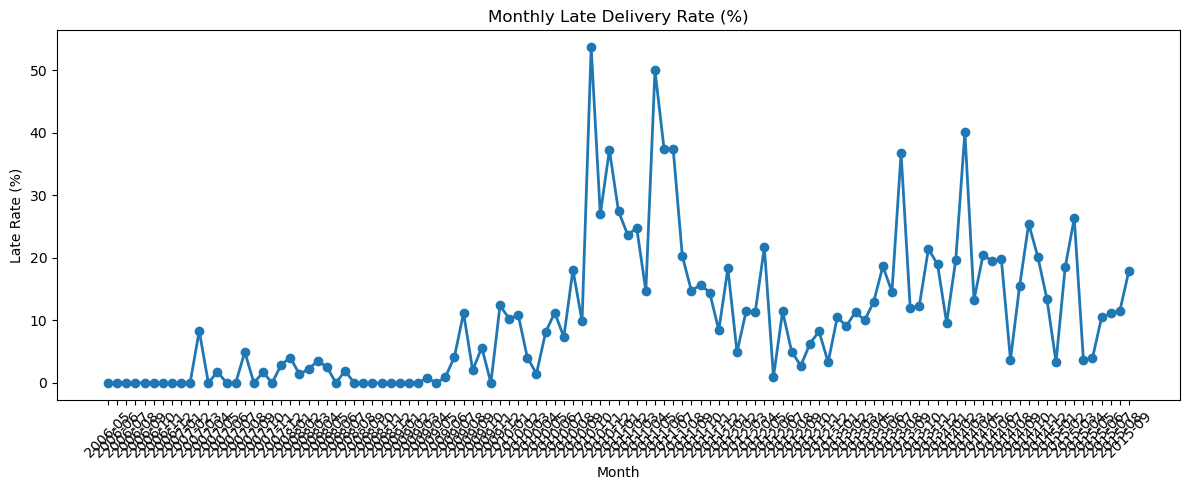

C:\Users\S B\AppData\Local\Temp\ipykernel_3512\2907345775.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_top, x='Late_Rate_%', y='Country', palette='viridis')


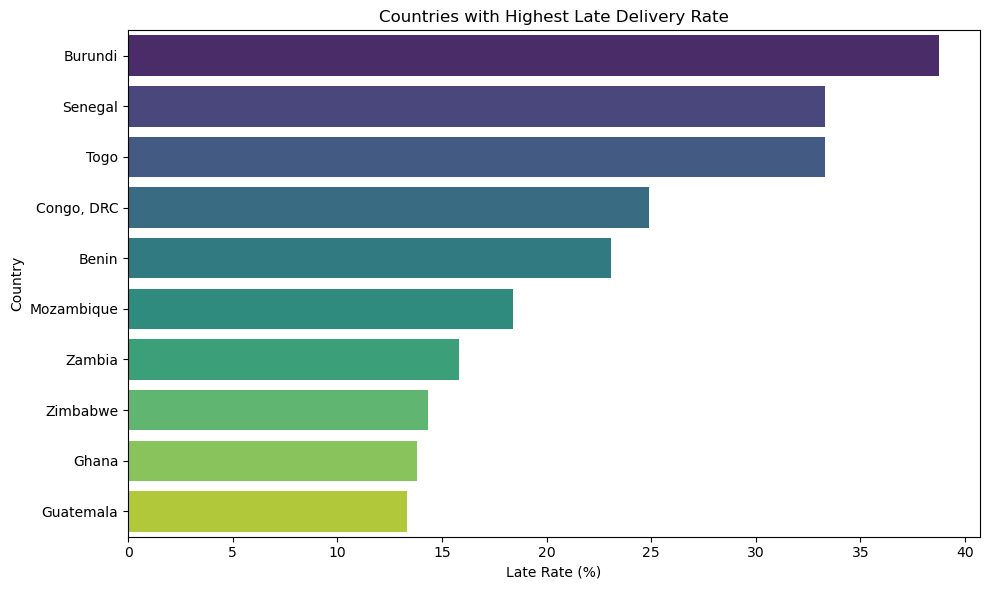

C:\Users\S B\AppData\Local\Temp\ipykernel_3512\2907345775.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendor_top, x='Late_Rate_%', y='Vendor', palette='magma')


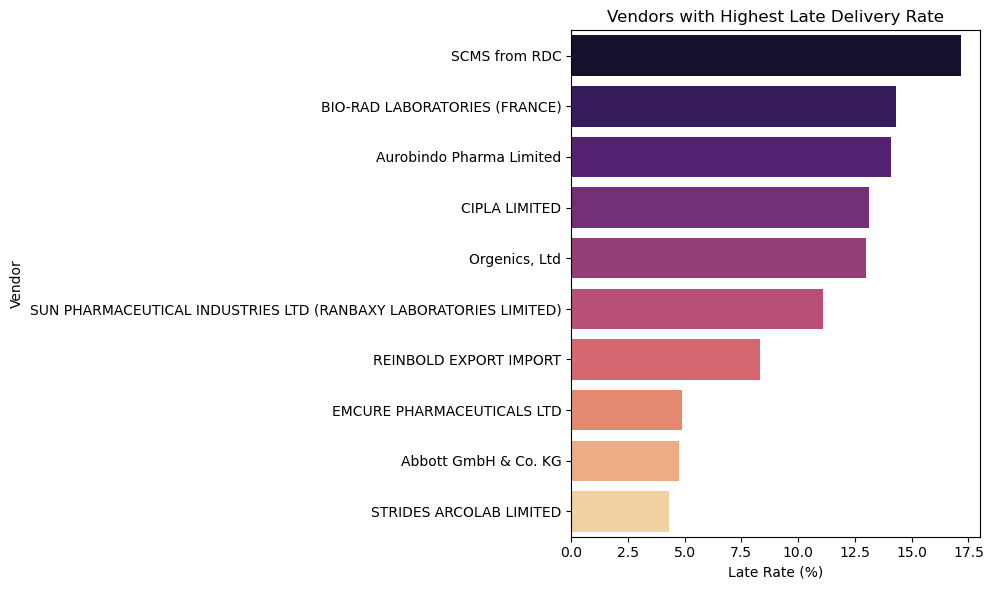


Executive summary:
- Total shipments analyzed: 10324
- Late shipment rate: 11.49%
- Average delivery delay: -6.02 days
- Highest-risk country: Burundi (38.78% late)
- Highest-risk vendor: SCMS from RDC (17.15% late)


In [28]:
# Analytics and Dashboard-ready KPI calculations

# 1) Monthly delivery trend
monthly_trend = (
    df_clean.groupby(df_clean['Delivery Recorded Date'].dt.to_period('M').astype(str))
    .agg(
        Total_Shipments=('ID', 'count'),
        On_Time=('Delivery_Status', lambda s: (s == 'On Time').sum()),
        Late=('Delivery_Status', lambda s: (s == 'Late').sum()),
        Avg_Delay=('Delivery_Delay_Days', 'mean')
    )
    .reset_index()
    .rename(columns={'Delivery Recorded Date': 'Month'})
)

monthly_trend['Late_Rate_%'] = (monthly_trend['Late'] / monthly_trend['Total_Shipments'] * 100).round(2)
monthly_trend['On_Time_Rate_%'] = (monthly_trend['On_Time'] / monthly_trend['Total_Shipments'] * 100).round(2)

print('\nMonthly delivery trend:')
print(monthly_trend.sort_values('Month').head(12).to_string(index=False))

# 2) Country and vendor dashboard views
country_dashboard = (
    df_clean.groupby('Country')
    .agg(
        Total_Shipments=('ID', 'count'),
        Late_Shipments=('Delivery_Status', lambda s: (s == 'Late').sum()),
        Avg_Delay=('Delivery_Delay_Days', 'mean')
    )
    .reset_index()
)
country_dashboard['Late_Rate_%'] = (country_dashboard['Late_Shipments'] / country_dashboard['Total_Shipments'] * 100).round(2)
country_dashboard = country_dashboard.sort_values('Late_Rate_%', ascending=False)

vendor_dashboard = (
    df_clean.groupby('Vendor')
    .agg(
        Total_Shipments=('ID', 'count'),
        Late_Shipments=('Delivery_Status', lambda s: (s == 'Late').sum()),
        Avg_Delay=('Delivery_Delay_Days', 'mean')
    )
    .reset_index()
)
vendor_dashboard['Late_Rate_%'] = (vendor_dashboard['Late_Shipments'] / vendor_dashboard['Total_Shipments'] * 100).round(2)
vendor_dashboard = vendor_dashboard.sort_values('Late_Rate_%', ascending=False)

print('\nTop 10 countries by late rate:')
print(country_dashboard.head(10).to_string(index=False))
print('\nTop 10 vendors by late rate:')
print(vendor_dashboard.head(10).to_string(index=False))

# 3) Dashboard visuals
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend['Month'], monthly_trend['Late_Rate_%'], marker='o', linewidth=2)
plt.title('Monthly Late Delivery Rate (%)')
plt.xlabel('Month')
plt.ylabel('Late Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
country_top = country_dashboard.head(10)
sns.barplot(data=country_top, x='Late_Rate_%', y='Country', palette='viridis')
plt.title('Countries with Highest Late Delivery Rate')
plt.xlabel('Late Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
vendor_top = vendor_dashboard.head(10)
sns.barplot(data=vendor_top, x='Late_Rate_%', y='Vendor', palette='magma')
plt.title('Vendors with Highest Late Delivery Rate')
plt.xlabel('Late Rate (%)')
plt.ylabel('Vendor')
plt.tight_layout()
plt.show()

# 4) Executive summary for thesis/dashboard narrative
print('\nExecutive summary:')
print(f"- Total shipments analyzed: {df_clean.shape[0]}")
print(f"- Late shipment rate: {late_rate:.2f}%")
print(f"- Average delivery delay: {avg_delay:.2f} days")
print(f"- Highest-risk country: {country_dashboard.iloc[0]['Country']} ({country_dashboard.iloc[0]['Late_Rate_%']:.2f}% late)")
print(f"- Highest-risk vendor: {vendor_dashboard.iloc[0]['Vendor']} ({vendor_dashboard.iloc[0]['Late_Rate_%']:.2f}% late)")
